In [1]:
import os
print(os.getcwd())


C:\Users\ashu1\anaconda_projects\e3bfa85e-09e2-4d45-a362-4f87c5d95399


In [3]:
import json
import os

# file names
json_path = "annotation_intel.json"
output_csv = "labels_intel.csv"

with open(json_path, 'r') as f:
    data = json.load(f)

output = []

for item in data:
    
    # skip if no annotations
    if not item.get('annotations'):
        continue
    
    ann = item['annotations'][0]
    
    # skip if no result
    if not ann.get('result'):
        continue

    # get image path
    image_path = item['data']['image']
    
    # extract filename safely
    filename = image_path.split('=')[-1].split('\\')[-1]
    
    # get label
    label = ann['result'][0]['value']['choices'][0]
    
    output.append((filename, label))

# save CSV
with open(output_csv, "w") as f:
    f.write("image,label\n")
    for row in output:
        f.write(f"{row[0]},{row[1]}\n")

print(f"Done! {output_csv} created")

Done! labels_intel.csv created


In [4]:
import pandas as pd
import urllib.parse

# load your Intel labels file
df = pd.read_csv("labels_intel.csv")

# clean paths
df['image'] = df['image'].astype(str)  # ensure string
df['image'] = df['image'].apply(lambda x: urllib.parse.unquote(x))  # decode URL
df['image'] = df['image'].apply(lambda x: x.split("\\")[-1].split("/")[-1])  # handle both \ and /

# save cleaned file
df.to_csv("labels_intel_clean.csv", index=False)

print(df.head())

                image     label
0   Buildings (1).jpg  Building
1  Buildings (10).jpg  Building
2  Buildings (11).jpg  Building
3  Buildings (13).jpg  Building
4  Buildings (14).jpg  Building


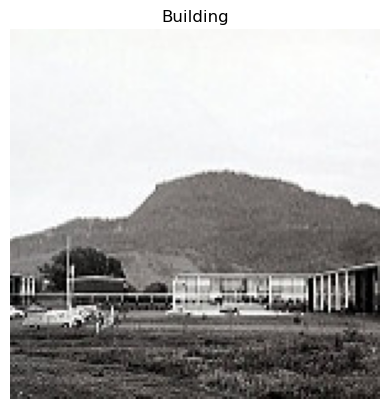

In [6]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import os

# load cleaned Intel CSV
df = pd.read_csv("labels_intel_clean.csv")

# path to images folder (change if your folder name is different)
img_dir = "images"   # or "images" if that's your folder

# take first image
img_name = df.iloc[0]['image']
img_path = os.path.join(img_dir, img_name)

# open and show
img = Image.open(img_path)

plt.imshow(img)
plt.title(df.iloc[0]['label'])
plt.axis('off')
plt.show()